# Access LSST alert cutouts served by $\texttt{Pitt-Google}$ via Google Cloud Storage

The $\texttt{Pitt-Google Alert Broker's}$ LSST Avro alert data (including cutouts) are stored in Google Cloud Storage (GCS). The GCS bucket names and alert Avro filename syntax are outlined in our [data listings page](https://mwvgroup.github.io/pittgoogle-client/listings.html#cloud-storage-buckets).

## Table of Contents

- [Extract a LSST alert from $\texttt{Pitt-Google}$'s GCS bucket](#extract-a-lsst-alert-from-pitt-googles-gcs-bucket)
- [Inspect cutout data from a LSST alert](#inspect-cutout-data-from-a-lsst-alert)
- [Plot cutouts from a LSST alert](#plot-cutouts-from-a-lsst-alert)

## Prerequisites

- Complete the One-Time Setup, specifically:
     - Install the pittgoogle-client package
     - Setup authentication to a Google Cloud project
     - Set environment variables
     - Enable the Google Cloud Storage API
     - You can skip the command-line tools

In [1]:
import io
import matplotlib.pyplot as plt
import pittgoogle
from astropy.io import fits
from google.cloud import storage
from google.cloud.pubsub_v1.types import PubsubMessage

<a id="extract-a-lsst-alert-from-pitt-googles-gcs-bucket"></a>
## Extract a LSST alert from $\texttt{Pitt-Google}$'s GCS bucket

LSST alert Avro files are *objects* stored in a GCS bucket. Extracting an alert from the bucket requires defining a filepath, or list of filepaths, to the Avro file(s).


$\texttt{Pitt-Google}$ uses the following syntax to store Avro file archives of the LSST alert stream:
- `v<alert_schema_version>/kafkaPublishTimestamp=<kafka_timestamp>/<objectid_key>=<objectid>/<sourceid_key>=<sourceid>.avro`

Examples are outlined below:
- `v10_0/kafkaPublishTimestamp=2026-02-25/diaObjectId=170028526486945858/diaSourceId=170055002405994505.avro`
- `v11_0_kafkaPublishTimestamp=2026-05-22/ssObjectId=21164723874183510/diaSourceId=170433141484815220.avro`
- `v11_1/kafkaPublishTimestamp=2026-07-14/diaObjectId=170019696269590551/diaSourceId=170666304476282912.avro`

Run the cells below to extract a LSST alert (`diaObjectId = 170028526486945858`, `diaSourceId = 170055002405994505`) from $\texttt{Pitt-Google}$'s GCS bucket and inspect its content.

In [2]:
def extract_alert(survey, alert_path, credentials):
    """Downloads an alert's Avro file from GCS and parses it into a pittgoogle Alert object.

    Args:
        survey (str): Name of the survey the alert belongs to (e.g. "lsst", "ztf"). Determines which GCP project and
            bucket the alert is fetched from, and which schema is used to parse it.
        alert_path (str): Path (blob name) of the alert's Avro file within the survey's GCS bucket.
        credentials (google.auth.credentials.Credentials): Credentials used to authenticate with GCS.

    Returns:
        pittgoogle.alert.Alert: The parsed alert object, constructed from the downloaded Avro bytes.
    """

    # define GCP resources
    if survey == "lsst":
        project_id = "pitt-alert-broker"
    else:
        project_id = "ardent-cycling-243415"

    bucket_obj = get_gcs_bucket(credentials, project_id, survey)

    # load the alert bytes from the GCS bucket
    blob = bucket_obj.blob(alert_path)
    avro_bytes = blob.download_as_bytes()

    # create Alert object
    pubsub_message = PubsubMessage(data=avro_bytes, attributes={})
    alert = pittgoogle.alert.Alert.from_msg(pubsub_message, schema_name=f"{survey}")

    # extract relevant metadata and add it to the Alert attributes
    blob.reload()

    return alert


def get_gcs_bucket(credentials, project_id, survey):
    """Gets a reference to a survey's alert-storage bucket in Google Cloud Storage.

    Args:
        credentials (google.auth.credentials.Credentials): Credentials used to authenticate with GCS.
        project_id (str): ID of the GCP project that owns the bucket.
        survey (str): Name of the survey, used to construct the bucket name (as "{project_id}-{survey}_alerts").

    Returns:
        google.cloud.storage.bucket.Bucket: The bucket containing the survey's alerts.
    """

    bucket_name = f"{project_id}-{survey}_alerts"

    client = storage.Client(project=project_id, credentials=credentials)
    bucket_name = f"{project_id}-{survey}_alerts"

    return client.get_bucket(client.bucket(bucket_name, user_project=project_id))

In [3]:
# load authenticate credentials
user_auth = pittgoogle.auth.Auth(
    GOOGLE_CLOUD_PROJECT="name-of-your-gcp-project", # UPDATE ME
    GOOGLE_APPLICATION_CREDENTIALS="path-to-service-account-key", # UPDATE ME
)

# define variables to extract a single alert object from GCS
VERSIONTAG = "v10_0"
DATE = "2026-02-25" # YYYY-MM-DD format required
DIAOBJECTID = "170028526486945858"
DIASOURCEID = "170055002405994505"
alert_path = f"{VERSIONTAG}/kafkaPublishTimestamp={DATE}/diaObjectId={DIAOBJECTID}/diaSourceId={DIASOURCEID}.avro"

# extract alert and inspect content
alert = extract_alert(survey="lsst", alert_path=alert_path, credentials=user_auth.credentials)
alert.dict

{'diaSourceId': 170055002405994505,
 'observation_reason': 'alert_m49',
 'target_name': 'field_m49, lowdust',
 'diaSource': {'diaSourceId': 170055002405994505,
  'visit': 2026022401013,
  'detector': 86,
  'diaObjectId': 170028526486945858,
  'ssObjectId': 0,
  'parentDiaSourceId': 0,
  'midpointMjdTai': 61096.37795926014,
  'ra': 186.18888768641912,
  'raErr': 3.1212307476380374e-06,
  'dec': 6.589120193501987,
  'decErr': 4.013566467619967e-06,
  'ra_dec_Cov': -2.8481509685429618e-12,
  'x': 2093.19091796875,
  'xErr': 0.07455948740243912,
  'y': 312.3384704589844,
  'yErr': 0.05289125815033913,
  'centroid_flag': False,
  'apFlux': 8084.974609375,
  'apFluxErr': 293.2948913574219,
  'apFlux_flag': False,
  'apFlux_flag_apertureTruncated': False,
  'isNegative': False,
  'snr': 57.28433609008789,
  'psfFlux': 8018.916015625,
  'psfFluxErr': 138.0200653076172,
  'psfLnL': nan,
  'psfChi2': 1709.785400390625,
  'psfNdata': 1681,
  'psfFlux_flag': False,
  'psfFlux_flag_edge': False,
  

<a id="inspect-cutout-data-from-a-lsst-alert"></a>
## Inspect cutout data from a LSST alert

Every LSST alert contains the fields: `cutoutScience`, `cutoutTemplate`, and `cutoutDifference`. 

The variable-size cutouts will be sized so as to encompass the entire footprint of the detected source, but be no smaller than `30x30` pixels. The provided images will comprise of a flux (32 bit float), variance (32 bit float), and mask (at least 16 bit flags) planes, and include metadata necessary for further processing (e.g., WCS, zero-point, PSF, etc.). (source: [Data Products Definition Document](https://lse-163.lsst.io))

Run the cells below to decode and inspect the data of an alert cutout.

In [4]:
def decode_cutout(cutout_bytes):
    """Decode the FITS data from a byte string and return a numpy array."""
    with fits.open(io.BytesIO(cutout_bytes)) as hdul:
        return hdul[0].data

In [5]:
cutout_science_data = decode_cutout(alert.dict["cutoutScience"])
cutout_science_data

array([[ 8.31247711e+00, -1.35668993e-01,  1.70046272e+01,
        -1.50068974e+00,  6.57431841e-01, -1.79044952e+01,
         3.86246347e+00, -3.47089505e+00,  1.21131096e+01,
         6.20733547e+00, -5.01993608e+00, -2.26234865e+00,
         2.59329624e+01,  2.57236624e+00, -1.41330910e+01,
        -1.69519043e+01, -5.39627790e-01, -1.69087009e+01,
         1.85046387e+01,  6.89083099e+00, -1.39289846e+01,
        -1.09142275e+01, -3.78120613e+00,  7.68094158e+00,
         4.32099724e+00, -4.04630280e+00, -1.03302374e+01,
         9.87950611e+00,  4.47841883e-01, -1.60606937e+01],
       [-2.43933411e+01,  2.43525553e+00,  9.11197662e+00,
         3.18607926e+00, -4.05536270e+00,  1.10693035e+01,
        -1.45173101e+01, -1.03789988e+01,  4.58215237e-01,
         2.33918419e+01,  1.20718603e+01, -5.60440826e+00,
         3.69762917e+01,  1.53521423e+01,  2.35072398e+00,
        -1.67263174e+00, -9.12984276e+00, -7.74490881e+00,
        -5.62537479e+00,  1.75207806e+01, -1.01220970e+

<a id="plot-cutouts-from-a-lsst-alert"></a>
## Plot cutouts from a LSST alert

Use the cells below to plot the individual cutouts of a LSST alert packet.

In [6]:
def plot_cutouts(alert_dict):
    """Plots the science, template, and difference postage cutouts for an alert.

    Decodes and displays each cutout image side by side in a single figure. If a cutout is missing or fails to decode,
    its panel is labeled with an error instead of an image.

    Args:
        alert_dict (dict): Alert data containing the cutout image bytes, keyed as "cutoutScience", "cutoutTemplate",
        and "cutoutDifference".

    Returns:
        None. Displays the figure via ``plt.show()``.
    """

    cutouts = ["Science", "Template", "Difference"]
    fig, axes = plt.subplots(1, 3)

    for i, cutout in enumerate(cutouts):
        key = f"cutout{cutout}"
        cutout_bytes = alert_dict[key]

        try:
            # decode and plot the stamp
            cutout_data = decode_cutout(cutout_bytes)
            axes[i].imshow(cutout_data, origin="lower", cmap="gray")
            axes[i].set_title(cutout)
        except Exception as e:
            axes[i].set_title(f"{cutout} (Error)")
            print(f"Error processing {cutout}: {e}")
            axes[i].axis("off")

    plt.tight_layout()
    plt.show()

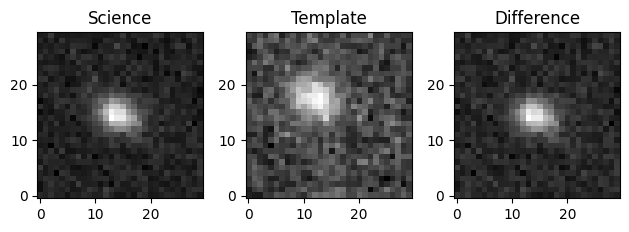

In [7]:
# plot cutouts
plot_cutouts(alert.dict)